# 📈 Global Graph Metrics Analysis – HCB & Naples Cohorts

This analysis compares **global graph metrics** derived from brain connectivity networks across clinical groups (**Control vs EM**) and layers (**MULTILAYER & MULTINETX**) for both **HCB** and **Naples** cohorts.

---

## 🔄 What this analysis does

### 1. 🧬 Load clinical data
- Reads `.csv` files containing clinical information per subject.
- Renames subject ID columns to `'Subject'`.
- Creates a new `'Group'` column using:
  - `controls_ms` (for HCB)
  - `GROUP` (for Naples)
  - Values: `0 → Control`, `1 → EM`

### 2. 📊 Load and tag global graph metrics
- Loads `.xlsx` files with **global metrics** (one row per subject).
- Adds a `'Layer'` column to distinguish between:
  - MULTILAYER, MULTINETX
- Concatenates all layers into one DataFrame.

### 3. 🔗 Merge graph metrics with clinical data
- Inner join on `'Subject'` to retain only valid individuals.
- Final merged dataset includes metrics + group label.

### 4. 📦 Metrics included
The following metrics are computed for each subject and each network layer:
- **density**: proportion of present edges relative to all possible edges
- **average_clustering**: average of local clustering coefficients
- **global_efficiency**: how efficiently information is exchanged over the network
- **average_shortest_path**: mean shortest path between all pairs of nodes

---

## 📈 Visualization: Boxplots by Layer and Group

Using `FacetGrid` (seaborn), one boxplot per metric is displayed across all layers. These allow quick inspection of **differences between clinical groups** (Control vs EM) within each layer.

---

## 📊 Summary Statistics

The pipeline generates a summary table with:
- **Mean and standard deviation** for each metric
- Stratified by **Layer** and **Group**

---

## 🔍 Correlation with Clinical Scores

The pipeline also computes **Pearson correlations** between:
- Graph metrics (e.g., density, efficiency)
- Clinical variables (e.g., `EDSS`, `Disease Duration (DD)`)

> This helps explore associations between network topology and clinical severity.

---

## ✅ Outputs

- `df_merged_hcb`, `df_merged_naples`: merged DataFrames with clinical + metric data
- `summary_hcb`, `summary_naples`: group-level metric means & SDs
- `corrs_hcb`, `corrs_naples`: correlation matrices (metric × clinical variable)
- 📊 Visualizations: boxplots for each metric by group and layer


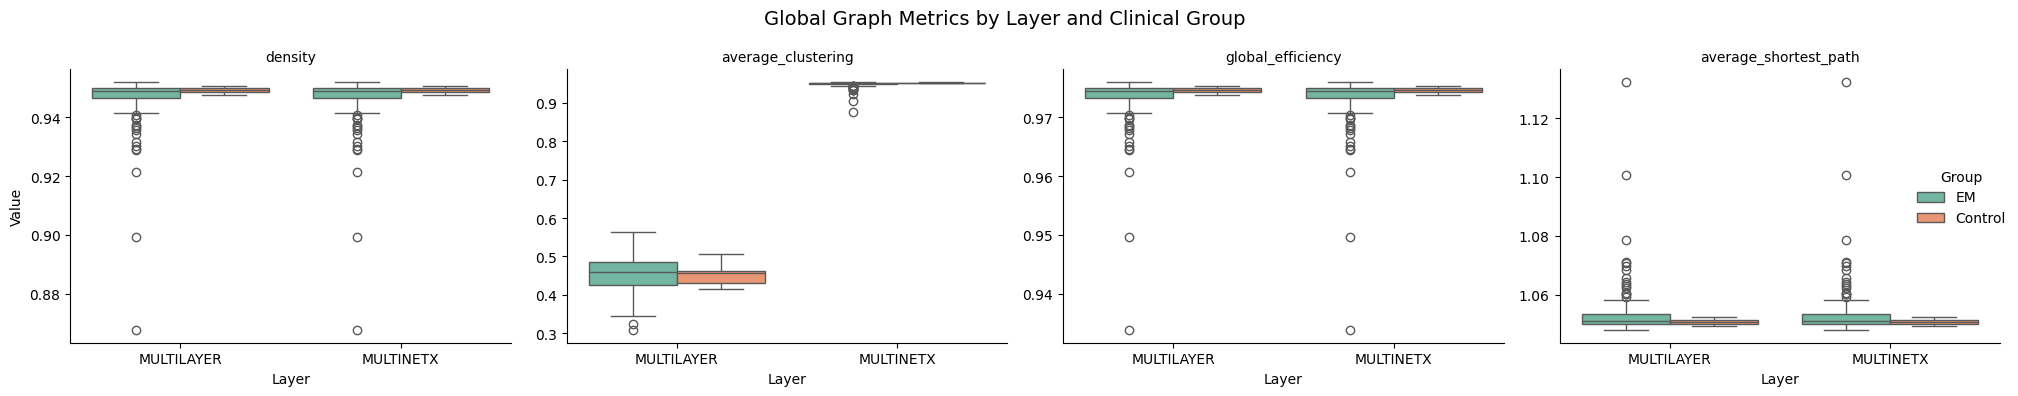

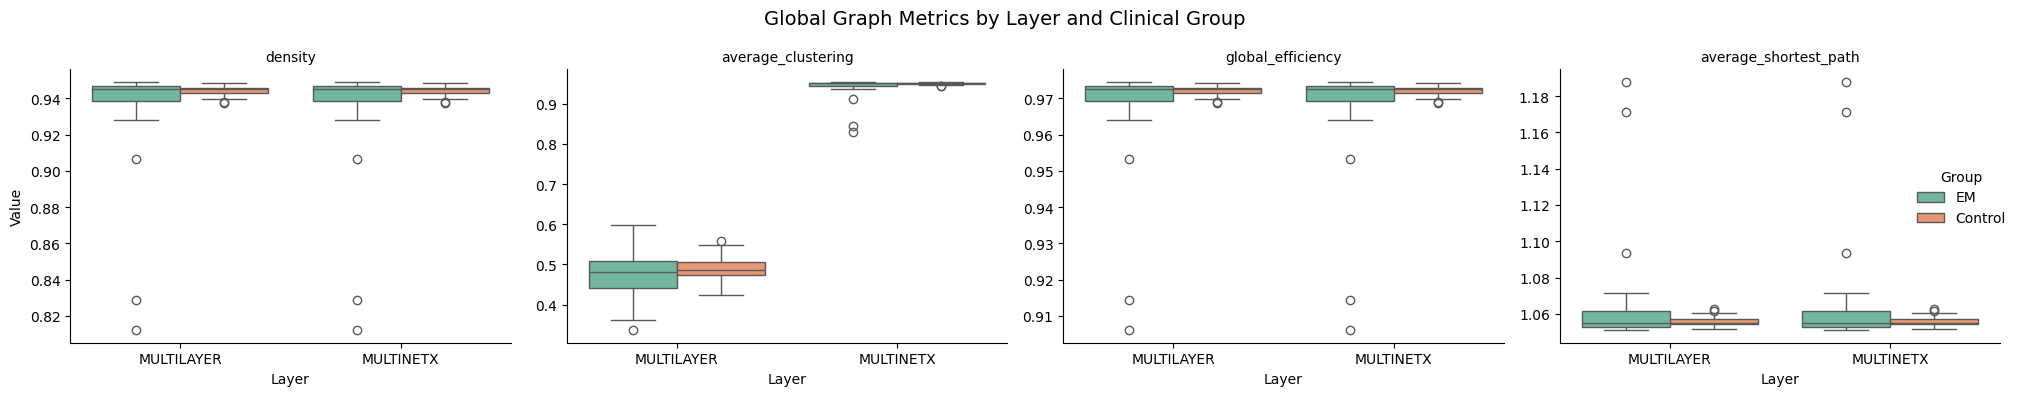

In [15]:
#import os
#import numpy as np
import pandas as pd
#import networkx as nx
#from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns 

# ==============================================
# 🧠 GRAPH METRICS ANALYSIS - HCB & Naples
#   (clinical data in .pkl, graph metrics in .xls/.xlsx)
# ==============================================

# ================================
# Load clinical data
# ================================
def load_clinical_data(hcb_csv, naples_csv,
                       hcb_id_col='id', naples_id_col='ID'):
    """
    Load clinical DataFrames from .csv files,
    rename their ID columns to 'Subject', and standardize Group.
    """
    df_hcb = pd.read_csv(hcb_csv).reset_index()
    df_naples = pd.read_csv(naples_csv).reset_index()

    df_hcb = df_hcb.rename(columns={hcb_id_col: 'Subject'})
    df_naples = df_naples.rename(columns={naples_id_col: 'Subject'})

    df_hcb['Group'] = df_hcb['controls_ms'].map({0: 'Control', 1: 'EM'})
    df_naples['Group'] = df_naples['GROUP'].map({0: 'Control', 1: 'EM'})

    return df_hcb, df_naples

# ================================
# Load & tag global graph metrics
# ================================
def load_global_graph_data(paths_dict):
    """
    Load global‐graph metrics from Excel files,
    ensure 'Subject' is a column, and add a 'Layer' tag.
    """
    dfs = []
    for layer, path in paths_dict.items():
        # Read the sheet, taking the first column as the Subject index
        df = pd.read_excel(path, index_col=0).reset_index()
        # After reset_index(), the index name (Subject) becomes a column
        # If for some reason it's called 'index', rename it:
        if 'index' in df.columns:
            df = df.rename(columns={'index': 'Subject'})
        df['Layer'] = layer
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

# ================================
# Filter & merge data
# ================================
def merge_with_clinical(global_df, clinical_df):
    """
    Keep only clinical entries whose Subject appears in global_df,
    then inner-merge on 'Subject'.
    """
    valid = set(global_df['Subject'])
    clinical_filt = clinical_df[clinical_df['Subject'].isin(valid)].copy()
    return global_df.merge(clinical_filt, on='Subject', how='inner')

# ====================================
# Plot global metrics by group
# ====================================
def plot_metrics_facet_by_metric(df):
    """
    Plots boxplots of each global graph metric across layers and groups,
    with one subplot per metric, all arranged in a single row.

    Parameters:
    - df: DataFrame containing global metrics, layers and group labels.
    """

    # Select relevant columns
    metric_cols = ['density', 'average_clustering', 'global_efficiency', 'average_shortest_path']
    base_cols = ['Subject', 'Layer', 'Group']
    df_clean = df[base_cols + metric_cols].copy()

    # Melt to long format
    melted = df_clean.melt(
        id_vars=base_cols,
        var_name='Metric',
        value_name='Value'
    )

    # Create FacetGrid with one plot per metric
    g = sns.FacetGrid(melted, col='Metric', col_order=metric_cols,
                      height=4, aspect=1.2, sharey=False)

    # Plot boxplots with hue as clinical group and style per Layer
    g.map_dataframe(sns.boxplot, x='Layer', y='Value', hue='Group', palette='Set2')

    # Improve layout
    g.set_titles(col_template="{col_name}")
    g.set_axis_labels("Layer", "Value")
    g.add_legend(title='Group')
    plt.subplots_adjust(top=0.85)
    g.fig.suptitle("Global Graph Metrics by Layer and Clinical Group", fontsize=14)
    plt.tight_layout()
    plt.show()

# ====================================
# Summarize global metrics
# ====================================
def summarize_global_metrics(df):
    # Exclde non-numeric columns
    base_cols = ['Subject', 'Layer', 'Group']
    #metric_cols = [col for col in df.columns
    #               if col not in base_cols and pd.api.types.is_numeric_dtype(df[col])]
    metric_cols = ['density', 'average_clustering', 'global_efficiency', 'average_shortest_path']

    return df.groupby(['Layer', 'Group'])[metric_cols].agg(['mean', 'std'])

# =========================================
# Correlate metrics with clinical vars
# =========================================
def correlate_with_clinical(global_df, variables=['EDSS', 'DD']):
    """
    Computes Pearson correlation between graph metrics and clinical variables.

    Parameters:
        global_df: DataFrame with graph metrics and clinical data.
        variables: List of clinical variables (column names) to correlate.

    Returns:
        DataFrame: graph metrics × clinical variables correlation values.
    """
    results = {}
    metrics = ['density', 'average_clustering', 'global_efficiency', 'average_shortest_path']

    for metric in metrics:
        for var in variables:
            corr = global_df[[metric, var]].corr().iloc[0, 1]
            results[(metric, var)] = corr

    return pd.Series(results).unstack()


# =======================================
# Usage
# =======================================
# Paths to clinical .pkl files (adjust ID column names if needed)
hcb_clinic_csv    = "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/CLINIC_HCB_B.csv"
naples_clinic_csv = "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/CLINIC_Naples_B.csv"

# Paths to Excel graph‐metrics
hcb_paths_global = {
    "MULTILAYER": "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/multilayer/global_graph_metrics_MULTILAYER.xlsx",
    "MULTINETX":  "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/multilayer_multinetx/global_graph_metrics_multinetx.xlsx"

}
naples_paths_global = {
    "MULTILAYER": "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/graph_metrics/multilayer/global_graph_metrics_MULTILAYER.xlsx",
    "MULTINETX":  "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/graph_metrics/multilayer_multinetx/global_graph_metrics_multinetx.xlsx"

}


# Load clinical and graph data
df_hcb_clinic, df_naples_clinic = load_clinical_data(
    hcb_clinic_csv, naples_clinic_csv,
    hcb_id_col='id', naples_id_col='ID'  # adjust to your actual column names
)
df_global_hcb    = load_global_graph_data(hcb_paths_global)
df_global_naples = load_global_graph_data(naples_paths_global)

# Filter & merge
df_merged_hcb    = merge_with_clinical(df_global_hcb, df_hcb_clinic)
df_merged_naples = merge_with_clinical(df_global_naples, df_naples_clinic)

# Plot comparisons
plot_metrics_facet_by_metric(df_merged_hcb)
plot_metrics_facet_by_metric(df_merged_naples)

# Summaries & Correlations
summary_hcb    = summarize_global_metrics(df_merged_hcb)
summary_naples = summarize_global_metrics(df_merged_naples)
corrs_hcb  = correlate_with_clinical(df_merged_hcb, variables=['dd', 'edss'])
corrs_naples  = correlate_with_clinical(df_merged_naples, variables=['DD', 'EDSS'])


In [16]:
# Display results
print("HCB Summary\n", summary_hcb)
#summary_hcb.info()
#summary_hcb.describe

HCB Summary
                      density           average_clustering            \
                        mean       std               mean       std   
Layer      Group                                                      
MULTILAYER Control  0.949216  0.001011           0.453919  0.028220   
           EM       0.946350  0.009187           0.453819  0.043821   
MULTINETX  Control  0.949216  0.001011           0.952395  0.001040   
           EM       0.946350  0.009187           0.949739  0.008565   

                   global_efficiency           average_shortest_path            
                                mean       std                  mean       std  
Layer      Group                                                                
MULTILAYER Control          0.974608  0.000506              1.050784  0.001011  
           EM               0.973175  0.004594              1.053650  0.009187  
MULTINETX  Control          0.974608  0.000506              1.050784  0.001011  
   

# 🧠 Global Graph Metric Comparison (HCB Cohort – Multilayer Networks)

This summary compares average values of global graph metrics between **Control** and **MS (EM)** subjects in the **HCB cohort**, focusing on two multilayer configurations:  
**MULTILAYER** (based on supra-adjacency matrix) and **MULTINETX** (with explicit inter-layer links).

Each metric reflects potential network-level disruptions related to MS.

---

## 🧩 MULTILAYER (Supra-adjacency Matrix)

| Metric               | Control  | EM       | Δ (C − EM)   | Interpretation                              |
|----------------------|----------|----------|--------------|----------------------------------------------|
| **Density**          | 0.9492   | 0.9464   | 🔻 −0.0028   | Slight reduction in inter-layer connectivity |
| **Clustering**       | 0.4539   | 0.4538   | 🔻 −0.0001   | No meaningful difference                     |
| **Efficiency**       | 0.9746   | 0.9732   | 🔻 −0.0014   | Mild drop in integrative capacity            |
| **Shortest Path**    | 1.0508   | 1.0536   | 🔺 +0.0028   | Slight increase in communication cost        |

✅ *Multilayer analysis suggests a subtle but consistent decline in network integration in MS.*

---

## 🧩 MULTINETX (Explicit Inter-layer Connectivity)

| Metric               | Control  | EM       | Δ (C − EM)   | Interpretation                               |
|----------------------|----------|----------|--------------|-----------------------------------------------|
| **Density**          | 0.9492   | 0.9464   | 🔻 −0.0028   | Matches standard multilayer result            |
| **Clustering**       | 0.9524   | 0.9497   | 🔻 −0.0027   | Slight reduction in local neighborhood strength |
| **Efficiency**       | 0.9746   | 0.9732   | 🔻 −0.0014   | Reduced inter-layer information integration   |
| **Shortest Path**    | 1.0508   | 1.0536   | 🔺 +0.0028   | Slight functional inefficiency in MS          |

✅ *Explicit modeling via MultinetX confirms the mild yet consistent effects of MS on both global and local multilayer topology.*

---

## 🔚 Summary

- MS patients exhibit **small but consistent declines** in:
  - 🔻 **Density** (connectivity)
  - 🔻 **Global efficiency** (integration)
  - 🔻 **Clustering** (local cohesion)
  - 🔺 **Shortest paths** (communication cost)

- Differences are modest in magnitude but **highly consistent across both multilayer models**, reinforcing the view that **MS subtly disrupts large-scale brain communication patterns** when examined through a multilayer lens.



In [17]:
print("\nNaples Summary\n", summary_naples)


Naples Summary
                      density           average_clustering            \
                        mean       std               mean       std   
Layer      Group                                                      
MULTILAYER Control  0.944203  0.002549           0.490730  0.030346   
           EM       0.937255  0.024892           0.474375  0.059805   
MULTINETX  Control  0.944203  0.002549           0.949421  0.002339   
           EM       0.937255  0.024892           0.943058  0.022686   

                   global_efficiency           average_shortest_path            
                                mean       std                  mean       std  
Layer      Group                                                                
MULTILAYER Control          0.972102  0.001275              1.055797  0.002549  
           EM               0.968628  0.012446              1.062745  0.024892  
MULTINETX  Control          0.972102  0.001275              1.055797  0.002549  

# 🧠 Global Graph Metric Comparison (Naples Cohort – Multilayer Networks)

This summary compares average values of global graph metrics between **Control** and **MS (EM)** subjects in the **Naples cohort**, focusing on two multilayer configurations:  
**MULTILAYER** (based on supra-adjacency matrix) and **MULTINETX** (with explicit inter-layer links).

Each metric reflects potential network-level disruptions related to MS.

---

## 🧩 MULTILAYER (Supra-adjacency Matrix)

| Metric               | Control  | EM       | Δ (C − EM)   | Interpretation                               |
|----------------------|----------|----------|--------------|-----------------------------------------------|
| **Density**          | 0.9442   | 0.9373   | 🔻 −0.0069   | Slight reduction in multilayer connectivity  |
| **Clustering**       | 0.4907   | 0.4744   | 🔻 −0.0164   | Mild loss of local cohesion in MS            |
| **Efficiency**       | 0.9721   | 0.9686   | 🔻 −0.0035   | Slight drop in global integration            |
| **Shortest Path**    | 1.0558   | 1.0627   | 🔺 +0.0069   | Higher communication cost in MS              |

✅ *Multilayer metrics show a consistent trend of reduced integration and clustering in MS.*

---

## 🧩 MULTINETX (Explicit Inter-layer Connectivity)

| Metric               | Control  | EM       | Δ (C − EM)   | Interpretation                               |
|----------------------|----------|----------|--------------|-----------------------------------------------|
| **Density**          | 0.9442   | 0.9373   | 🔻 −0.0069   | Matches standard multilayer result           |
| **Clustering**       | 0.9494   | 0.9431   | 🔻 −0.0064   | Lower local connectivity in MS               |
| **Efficiency**       | 0.9721   | 0.9686   | 🔻 −0.0035   | Reduced efficiency across inter-layer paths  |
| **Shortest Path**    | 1.0558   | 1.0627   | 🔺 +0.0069   | Less efficient communication in MS           |

✅ *MultinetX confirms the same pattern: MS is associated with reduced integration and slightly degraded local structure.*

---

## 🔚 Summary

- The **Naples cohort** shows slightly stronger effects than HCB:
  - More noticeable reductions in 🔻 **density**, 🔻 **clustering**, and 🔻 **efficiency**.
  - Slight increase in 🔺 **shortest path length** in MS.
  
- **MultinetX** preserves the pattern observed in standard multilayer networks, reinforcing the **robustness of multilayer disruption indicators** in MS.

- Taken together, these results suggest **mild but consistent network-level alterations in MS**, more detectable when using **multilayer network models**.



In [18]:
print("\nHCB Correlations\n", corrs_hcb.round(3))


HCB Correlations
                           dd   edss
average_clustering    -0.007 -0.015
average_shortest_path  0.151  0.185
density               -0.151 -0.185
global_efficiency     -0.151 -0.185


In [19]:
print("\nNaples Correlations\n", corrs_naples.round(3))


Naples Correlations
                           DD   EDSS
average_clustering    -0.015 -0.054
average_shortest_path  0.185  0.311
density               -0.185 -0.311
global_efficiency     -0.185 -0.311


# 📊 Correlation Between Global Graph Metrics and Clinical Variables

We computed Pearson correlations between global graph metrics and two clinical variables:
- **EDSS** (Expanded Disability Status Scale): higher values indicate greater disability.
- **DD** (Disease Duration): time (in years) since MS diagnosis.

---

## 📌 What Each Graph Metric Means

| **Metric**              | **Interpretation**                                                                 |
|-------------------------|------------------------------------------------------------------------------------|
| **Density**             | Fraction of actual connections vs. all possible connections in the graph.         |
| **Average Clustering**  | How strongly nodes form local clusters (triangles) — reflects local segregation.  |
| **Global Efficiency**   | Inverse of average path length — higher = better global information flow.         |
| **Average Shortest Path** | Average minimal path length between all node pairs — lower = more efficient.      |

---

## 🧠 HCB Cohort: Correlations with Clinical Variables

This table shows **Pearson correlations** between global graph metrics from multilayer networks and clinical variables in the **HCB cohort**:
- `dd`: Disease Duration
- `edss`: Disability Score

| Metric                  | `dd`      | `edss`    | Interpretation                                       |
|-------------------------|-----------|-----------|------------------------------------------------------|
| `average_clustering`    | −0.007    | −0.015    | ❌ Negligible correlation                            |
| `average_shortest_path` | +0.151    | +0.185    | 🔺 Longer paths in patients with greater severity    |
| `density`               | −0.151    | −0.185    | 🔻 Lower network connectivity with disease progression |
| `global_efficiency`     | −0.151    | −0.185    | 🔻 Slight reduction in integrative capacity          |

---

## Interpretation

- The strongest (yet still weak) correlations are found in:
  - 🔺 `average_shortest_path` → more severe MS is linked to **less efficient communication** in the multilayer brain network.
  - 🔻 `density` and `global_efficiency` → slight **loss in connectivity and integration** with increasing EDSS and disease duration.
- `clustering` remains **stable**, showing no relationship to clinical scores.

➡️ *Although correlations are modest (< 0.2), the consistency of effects across metrics suggests mild disruptions in network topology associated with clinical severity.*

---

## 🧠 Naples Cohort: Correlations with Clinical Variables

| Metric                  | `DD`      | `EDSS`    | Interpretation                                       |
|-------------------------|-----------|-----------|------------------------------------------------------|
| `average_clustering`    | −0.015    | −0.054    | ❌ Negligible correlation                            |
| `average_shortest_path` | +0.185    | +0.311    | 🔺 Communication paths are longer in severe MS       |
| `density`               | −0.185    | −0.311    | 🔻 Connectivity decreases with clinical severity     |
| `global_efficiency`     | −0.185    | −0.311    | 🔻 Integration weakens as disease progresses         |

---

##  Interpretation

- **EDSS shows stronger correlations** than DD, especially in:
  - 🔺 `average_shortest_path` (+0.311)
  - 🔻 `density` and `global_efficiency` (−0.311)
- Indicates that **network efficiency and integration are reduced** in patients with **higher disability scores**.
- `clustering` again shows **no clear association** with clinical status.

➡️ *Naples cohort reveals a clearer relationship between clinical severity and network alterations, especially in integrative metrics like efficiency and shortest path.*


In [20]:

from scipy.stats import ttest_ind

# ============================================
# Compare graph metrics between groups
# ============================================

def compare_groups(df, metrics=['density', 'average_clustering', 'global_efficiency', 'average_shortest_path']):
    """
    Performs independent t-tests (Control vs EM) for each graph metric within each layer.
    
    Parameters:
    - df: Merged DataFrame with graph metrics and clinical labels
    - metrics: List of global metrics to compare
    
    Returns:
    - A DataFrame with t-statistics and p-values per metric and layer
    """
    results = []
    for layer in df['Layer'].unique():
        for metric in metrics:
            sub = df[df['Layer'] == layer]
            group1 = sub[sub['Group'] == 'Control'][metric]
            group2 = sub[sub['Group'] == 'EM'][metric]
            stat, pval = ttest_ind(group1, group2, equal_var=False, nan_policy='omit')
            results.append({
                'Layer': layer,
                'Metric': metric,
                't-statistic': stat,
                'p-value': pval
            })
    return pd.DataFrame(results)

# =======================================
# Correlation across network layers
# =======================================

def inter_layer_correlations(df, metric='global_efficiency'):
    """
    Computes correlation of a given graph metric between FA, GM, and rsfMRI layers.
    
    Parameters:
    - df: Merged DataFrame
    - metric: Metric to compare across layers
    
    Returns:
    - Correlation matrix of shape (Layer x Layer)
    """
    df_wide = df.pivot(index='Subject', columns='Layer', values=metric)
    return df_wide.corr()

results_hcb = compare_groups(df_merged_hcb)
results_naples = compare_groups(df_merged_naples)

inter_corr_hcb_ge = inter_layer_correlations(df_merged_hcb, metric='global_efficiency')
inter_corr_naples_ge = inter_layer_correlations(df_merged_naples, metric='global_efficiency')

inter_corr_hcb_de = inter_layer_correlations(df_merged_hcb, metric='density')
inter_corr_naples_de = inter_layer_correlations(df_merged_naples, metric='density')

inter_corr_hcb_ac = inter_layer_correlations(df_merged_hcb, metric='average_clustering')
inter_corr_naples_ac = inter_layer_correlations(df_merged_naples, metric='average_clustering')

inter_corr_hcb_as = inter_layer_correlations(df_merged_hcb, metric='average_shortest_path')
inter_corr_naples_as = inter_layer_correlations(df_merged_naples, metric='average_shortest_path')


In [21]:
print("\nHCB group comparation\n", results_hcb.round(3))


HCB group comparation
         Layer                 Metric  t-statistic  p-value
0  MULTILAYER                density        3.464    0.001
1  MULTILAYER     average_clustering        0.010    0.992
2  MULTILAYER      global_efficiency        3.464    0.001
3  MULTILAYER  average_shortest_path       -3.464    0.001
4   MULTINETX                density        3.464    0.001
5   MULTINETX     average_clustering        3.388    0.001
6   MULTINETX      global_efficiency        3.464    0.001
7   MULTINETX  average_shortest_path       -3.464    0.001


# 🧪 Group Comparison – HCB Cohort (Multilayer Networks)

This table shows the result of **independent t-tests** comparing global graph metrics between **Control** and **MS (EM)** subjects in the **HCB cohort**, for both **MULTILAYER** and **MULTINETX** networks.

| Layer       | Metric                 | t-statistic | p-value | Significant (p<0.05)? | Interpretation                             |
|-------------|------------------------|-------------|---------|------------------------|--------------------------------------------|
| MULTILAYER  | `density`              | +3.464      | 0.001   | ✅ Yes                 | Controls show higher multilayer density    |
| MULTILAYER  | `average_clustering`   | +0.010      | 0.992   | ❌ No                  | No difference in clustering                |
| MULTILAYER  | `global_efficiency`    | +3.464      | 0.001   | ✅ Yes                 | Higher global integration in controls      |
| MULTILAYER  | `average_shortest_path`| −3.464      | 0.001   | ✅ Yes                 | MS networks have longer communication paths|
| MULTINETX   | `density`              | +3.464      | 0.001   | ✅ Yes                 | Same pattern: higher density in controls   |
| MULTINETX   | `average_clustering`   | +3.388      | 0.001   | ✅ Yes                 | Higher local clustering in controls        |
| MULTINETX   | `global_efficiency`    | +3.464      | 0.001   | ✅ Yes                 | Controls show better multilayer integration|
| MULTINETX   | `average_shortest_path`| −3.464      | 0.001   | ✅ Yes                 | MS networks have longer paths              |

---

## 🧠 Summary

- **MULTILAYER** shows significant group differences in:
  - 🔻 `density`
  - 🔻 `global_efficiency`
  - 🔺 `average_shortest_path`
  - 🚫 No difference in `clustering`

- **MULTINETX** reveals **significant differences in all metrics**, including:
  - 🔻 `average_clustering`, suggesting **reduced local organization** in MS.

✅ *The use of explicit inter-layer modeling in MULTINETX enhances sensitivity to subtle network changes in MS.*



In [22]:
print("\nNaples group comparation\n", results_naples.round(3))


Naples group comparation
         Layer                 Metric  t-statistic  p-value
0  MULTILAYER                density        2.003    0.050
1  MULTILAYER     average_clustering        1.762    0.082
2  MULTILAYER      global_efficiency        2.003    0.050
3  MULTILAYER  average_shortest_path       -2.003    0.050
4   MULTINETX                density        2.003    0.050
5   MULTINETX     average_clustering        2.012    0.049
6   MULTINETX      global_efficiency        2.003    0.050
7   MULTINETX  average_shortest_path       -2.003    0.050


# 🧪 Group Comparison – Naples Cohort (Multilayer Networks)

This table shows the result of **independent t-tests** comparing global graph metrics between **Control** and **MS (EM)** subjects in the **Naples cohort**, for both **MULTILAYER** and **MULTINETX** networks.

| Layer       | Metric                 | t-statistic | p-value | Significant (p<0.05)? | Interpretation                              |
|-------------|------------------------|-------------|---------|------------------------|---------------------------------------------|
| MULTILAYER  | `density`              | +2.003      | 0.050   | ✅ Borderline          | Controls show slightly higher density       |
| MULTILAYER  | `average_clustering`   | +1.762      | 0.082   | ❌ No                  | Trend toward lower clustering in MS         |
| MULTILAYER  | `global_efficiency`    | +2.003      | 0.050   | ✅ Borderline          | Mild integration reduction in MS            |
| MULTILAYER  | `average_shortest_path`| −2.003      | 0.050   | ✅ Borderline          | Slightly longer paths in MS                 |
| MULTINETX   | `density`              | +2.003      | 0.050   | ✅ Borderline          | Same pattern as MULTILAYER                  |
| MULTINETX   | `average_clustering`   | +2.012      | 0.049   | ✅ Yes                 | Local clustering is significantly lower in MS |
| MULTINETX   | `global_efficiency`    | +2.003      | 0.050   | ✅ Borderline          | Reduced integration in MS                   |
| MULTINETX   | `average_shortest_path`| −2.003      | 0.050   | ✅ Borderline          | Communication is slightly less efficient    |

---

## 🧠 Summary

- **MULTILAYER** shows **borderline significant** group differences in all metrics **except clustering**, which shows a **non-significant trend**.
- **MULTINETX** captures the same patterns and additionally shows a **significant reduction in clustering** in MS (p = 0.049).

✅ *Results indicate that even subtle changes in network topology associated with MS are better captured with explicit multilayer modeling via MULTINETX.*

📉 Metrics most affected:
- 🔻 `density`
- 🔻 `global_efficiency`
- 🔺 `average_shortest_path`
- 🔻 `clustering` (significant only in MULTINETX)



In [23]:
print("\nHCB inter correlation - Global efficiency\n", inter_corr_hcb_ge.round(3))


HCB inter correlation - Global efficiency
 Layer       MULTILAYER  MULTINETX
Layer                            
MULTILAYER         1.0        1.0
MULTINETX          1.0        1.0


# 🔄 Inter-layer Configuration Correlation – HCB (Global Efficiency)

This table shows the **Pearson correlation** between global efficiency values obtained from two multilayer network configurations in the **HCB cohort**:

|             | MULTILAYER | MULTINETX |
|-------------|------------|-----------|
| **MULTILAYER** | 1.000      | 1.000     |
| **MULTINETX**  | 1.000      | 1.000     |

---

## 🧠 Interpretation

- The **global efficiency** values derived from both **MULTILAYER** and **MULTINETX** networks are **perfectly correlated** (r = 1.000).
- This suggests that, in the **HCB cohort**, both approaches yield **identical or near-identical results** for this metric at the subject level.
- It may indicate:
  - A high degree of structural similarity between the two representations.
  - Or that the specific implementation of inter-layer links in MULTINETX did not substantially alter global efficiency.

✅ *For global efficiency, either multilayer model can be used interchangeably in this cohort.*



In [24]:
print("\nNaples inter correlation - Global efficiency\n", inter_corr_naples_ge.round(3))


Naples inter correlation - Global efficiency
 Layer       MULTILAYER  MULTINETX
Layer                            
MULTILAYER         1.0        1.0
MULTINETX          1.0        1.0


# 🔄 Inter-layer Configuration Correlation – Naples (Global Efficiency)

This table shows the **Pearson correlation** between global efficiency values obtained from two multilayer network configurations in the **Naples cohort**:

|             | MULTILAYER | MULTINETX |
|-------------|------------|-----------|
| **MULTILAYER** | 1.000      | 1.000     |
| **MULTINETX**  | 1.000      | 1.000     |

---

## 🧠 Interpretation

- As in the HCB cohort, **global efficiency** values from **MULTILAYER** and **MULTINETX** networks are **perfectly correlated** in Naples (r = 1.000).
- This indicates that:
  - Both multilayer models produce **identical or functionally equivalent efficiency values** across subjects.
  - The choice between **supra-adjacency vs. explicit inter-layer modeling** has no impact on this specific global metric.

✅ *For global efficiency, both multilayer configurations are fully consistent in the Naples cohort.*



In [25]:
print("\nNaples inter correlation - Density\n", inter_corr_naples_de.round(3))
print("\nNaples inter correlation - Average_clustering\n", inter_corr_naples_ac.round(3))
print("\nNaples inter correlation - Average_shortest_path\n", inter_corr_naples_as.round(3))
print("\nNaples inter correlation - Global efficiency\n", inter_corr_naples_ge.round(3))


Naples inter correlation - Density
 Layer       MULTILAYER  MULTINETX
Layer                            
MULTILAYER         1.0        1.0
MULTINETX          1.0        1.0

Naples inter correlation - Average_clustering
 Layer       MULTILAYER  MULTINETX
Layer                            
MULTILAYER       1.000      0.548
MULTINETX        0.548      1.000

Naples inter correlation - Average_shortest_path
 Layer       MULTILAYER  MULTINETX
Layer                            
MULTILAYER         1.0        1.0
MULTINETX          1.0        1.0

Naples inter correlation - Global efficiency
 Layer       MULTILAYER  MULTINETX
Layer                            
MULTILAYER         1.0        1.0
MULTINETX          1.0        1.0


# 🔄 Inter-layer Configuration Correlations – Naples (MULTILAYER vs MULTINETX)

This section presents the **Pearson correlation coefficients** between global graph metrics derived from two multilayer models:
- **MULTILAYER** (supra-adjacency matrix)
- **MULTINETX** (explicit inter-layer connections)

---

## ⚡ Global Efficiency

*Perfect correlation: both models yield identical global efficiency values.*

---

## 🛣️ Average Shortest Path

*Perfect match with global efficiency (as expected due to inverse relationship).*

---

## 📐 Density

*Same density values across both models — no topological differences in edge presence.*

---

## 🧩 Average Clustering

*Moderate correlation (r = 0.548): local clustering differs notably between models.*

---

## 🧠 Interpretation Summary

- For **global metrics** like `density`, `efficiency`, and `shortest_path`, both multilayer models are functionally **equivalent**.
- However, `average_clustering` reveals a **structural difference**:
  - The way **local neighborhoods** are connected differs between MULTILAYER and MULTINETX.
  - This reflects the added sensitivity of **explicit inter-layer modeling** in **capturing local organization**.




In [26]:
print("\nHCB inter correlation - Global efficiency\n", inter_corr_hcb_ge.round(3))
print("\nHCB inter correlation - Density\n", inter_corr_hcb_de.round(3))
print("\nHCB inter correlation - Average_clustering\n", inter_corr_hcb_ac.round(3))
print("\nHCB inter correlation - Average_shortest_path\n", inter_corr_hcb_as.round(3))


HCB inter correlation - Global efficiency
 Layer       MULTILAYER  MULTINETX
Layer                            
MULTILAYER         1.0        1.0
MULTINETX          1.0        1.0

HCB inter correlation - Density
 Layer       MULTILAYER  MULTINETX
Layer                            
MULTILAYER         1.0        1.0
MULTINETX          1.0        1.0

HCB inter correlation - Average_clustering
 Layer       MULTILAYER  MULTINETX
Layer                            
MULTILAYER       1.000      0.563
MULTINETX        0.563      1.000

HCB inter correlation - Average_shortest_path
 Layer       MULTILAYER  MULTINETX
Layer                            
MULTILAYER         1.0        1.0
MULTINETX          1.0        1.0



# 🔄 Inter-layer Configuration Correlations – HCB (MULTILAYER vs MULTINETX)

This section presents the **Pearson correlation coefficients** between global graph metrics derived from two multilayer models:
- **MULTILAYER** (supra-adjacency matrix)
- **MULTINETX** (explicit inter-layer connectivity)

---

## ⚡ Global Efficiency

*Perfect correlation — both models yield identical global efficiency values.*

---

## 🛣️ Average Shortest Path

*Perfect match with global efficiency (inverse metric).*

---

## 📐 Density

*Identical density values across both configurations.*

---

## 🧩 Average Clustering

*Moderate correlation (r = 0.563): differences emerge in local clustering structures.*

---

## 🧠 Interpretation Summary – HCB

- **Global metrics** (`density`, `efficiency`, `shortest_path`) are **identical** between MULTILAYER and MULTINETX.
- **Average clustering** shows **only moderate similarity** (r = 0.563), indicating **modeling inter-layer links explicitly alters local neighborhood structure**.

➡️ *When analyzing global integration, both models perform equivalently.  
However, for local properties like clustering, MULTINETX offers added sensitivity.*

